In [1]:
import cv2
from src.utils.func import (crop_center, read_image_as_numpyimage, get_corners,)
from src.utils.playfield_finder import PlayfieldFinder, Playfield, PlayfieldLines, PlayfiledPoints
import numpy as np
from src.utils.points import Point
from src.utils.plotting import display_img, plot_on_image
import src.config
from src.utils.metrics import iou
from src.utils.intersections import compute_intersections
from src.utils.annotations import transform_annotation
from pathlib import Path
import pandas as pd
from src.utils.annotations import PolygonAnnotation
import matplotlib.pyplot as plt
from src.utils.balls import BallDetector
from src.utils.const import BallColor

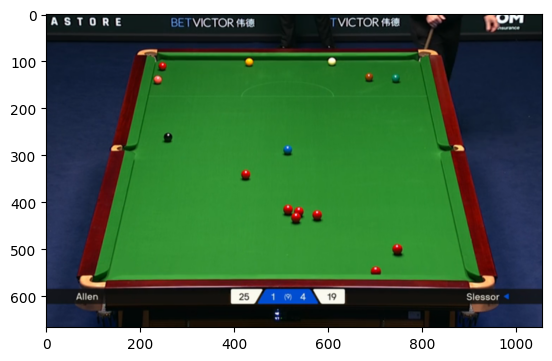

In [2]:
picname = 'pic_06_24_01'  # _06_09_02     pic_01_43_02
pic = read_image_as_numpyimage(f'pics/{picname}.png', 'rgb') # pic_02_07_01.png   pic_05_18_01.png  pic_08_08_01.png pic_06_16_02.png
cropped_pic = crop_center(pic)

display_img(pic)

In [3]:
finder = PlayfieldFinder(pic)
bottom_cushion = finder.find_bottom_internal_cushion()
top_cushion = finder.find_top_internal_cushion()
side_lines = finder.find_internal_side_cushions()
bottom_cushion, top_cushion, *side_lines

(y = 0.0 * x + 555.0,
 y = 0.0 * x + 90.0,
 y = -4.375 * x + 1124.625,
 y = 4.622641509433962 * x + -3577.509433962264)

In [5]:
all_lines = [bottom_cushion, top_cushion, *side_lines]
internal_intersection = compute_intersections(all_lines, pic)

lt, lb, rt, rb = get_corners(PlayfieldFinder.intersection_to_points_array(internal_intersection))

In [6]:
pf_points = PlayfiledPoints.from_numpy(lt, lb, rt, rb)
pf_points

PlayfiledPoints(top_left=Point(236, 90), top_right=Point(793, 90), bottom_right=Point(893, 555), bottom_left=Point(130, 555))

In [7]:
pf_lines = PlayfieldLines.from_lines(top_cushion, bottom_cushion, side_lines)
pf_lines

PlayfieldLines(top=y = 0.0 * x + 90.0, bottom=y = 0.0 * x + 555.0, left=y = -4.375 * x + 1124.625, right=y = 4.622641509433962 * x + -3577.509433962264)

In [8]:
pf = Playfield(lines=pf_lines, points=pf_points)

In [9]:
pf.points.to_numpy()

array([[236,  90],
       [793,  90],
       [893, 555],
       [130, 555]])

In [10]:
ball_detector = BallDetector(pic, pf)

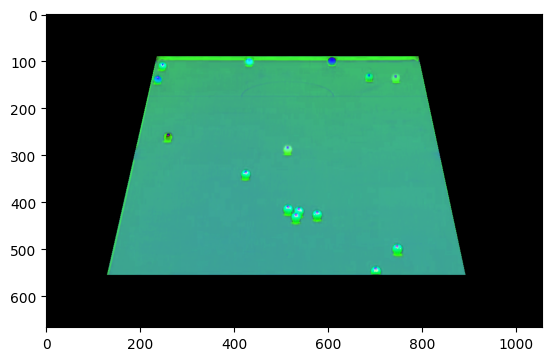

In [11]:
display_img(ball_detector._preprocess_image())

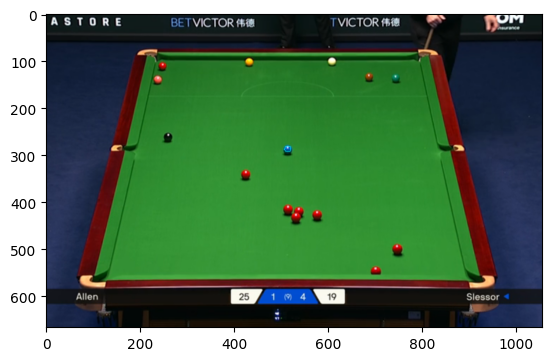

In [12]:
display_img(ball_detector.get_balls(BallColor.BLUE))

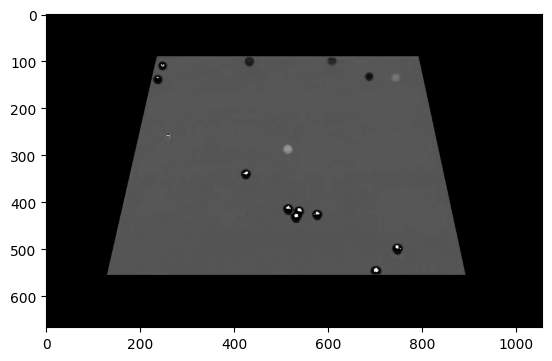

In [14]:
display_img(ball_detector._preprocess_image()[..., 0])